In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import sys
import random
import json
import re
from PIL import Image, ImageEnhance
import numpy as np

# ------------------------------------------------------------
# 1. 프로젝트 루트 경로
# ------------------------------------------------------------
BASE_DIR = Path('/content/drive/MyDrive/먼작귀')

# 측면 공통 py가 있는 폴더
PROJECT_DIR = BASE_DIR / 'synthetic_scenarios' / 'side'
COMMON_FILE = PROJECT_DIR / 'side_synthetic_shelf_common.py'

# 라벨 exporter가 있는 폴더
LABELER_DIR = BASE_DIR / 'synthetic_scenarios'
LABELER_FILE = LABELER_DIR / 'synthetic_label_exporter.py'

if not COMMON_FILE.exists():
    raise FileNotFoundError(f"측면 공통 py 파일을 찾지 못했습니다: {COMMON_FILE}")

if not LABELER_FILE.exists():
    raise FileNotFoundError(f"라벨 exporter 파일을 찾지 못했습니다: {LABELER_FILE}")

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

if str(LABELER_DIR) not in sys.path:
    sys.path.insert(0, str(LABELER_DIR))

# ------------------------------------------------------------
# 2. 측면 공통 py / 라벨 exporter import
# ------------------------------------------------------------
import side_synthetic_shelf_common as synth
import synthetic_label_exporter as labeler

ctx = synth.create_synthetic_context(
    base_dir=BASE_DIR,
    background_name='선반이미지_사이드.png',
    seed=42,
)

print('공통 py import 완료')
print('labeler import 완료')
print('공통 py 파일 위치:', COMMON_FILE)
print('라벨 exporter 파일 위치:', LABELER_FILE)
print('BASE_DIR:', BASE_DIR)
print('배경:', ctx['paths']['background_path'])
print('전체 slot 수:', len(ctx['all_slots']))
print('class 수:', len(ctx['class_map']))

# ------------------------------------------------------------
# 3. 다음 저장 번호 찾는 함수
# ------------------------------------------------------------
def get_next_start_index(image_dir, scenario_code):
    image_dir = Path(image_dir)
    pattern = re.compile(rf'^synthetic_{scenario_code.lower()}_(\d{{3,5}})\.png$')

    max_num = 0

    for p in image_dir.glob(f'synthetic_{scenario_code.lower()}_*.png'):
        m = pattern.match(p.name)

        if m:
            max_num = max(max_num, int(m.group(1)))

    return max_num + 1

# ------------------------------------------------------------
# 4. S6 측면 합성 기본 설정
# ------------------------------------------------------------
SCENARIO_CODE = 'S6'
SCENARIO_NAME = '복합 상황'

# 1차 실험용 S6 개수
NUM_IMAGES = 200
BASE_SEED = 660660

# SAHI 기준 최종 라벨 저장 경로
IMAGE_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'images' / 'side' / SCENARIO_CODE.lower()
PRODUCT_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo' / 'side' / SCENARIO_CODE.lower()
SHELF_LIP_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo_seg' / 'side' / SCENARIO_CODE.lower()
JSON_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_json' / 'slot_state' / 'side' / SCENARIO_CODE.lower()

for d in [IMAGE_DIR, PRODUCT_YOLO_DIR, SHELF_LIP_YOLO_DIR, JSON_DIR]:
    d.mkdir(parents=True, exist_ok=True)

start_idx = get_next_start_index(IMAGE_DIR, SCENARIO_CODE)

saved_paths = []
generation_logs = []
last_result = None

print('S6 경로 설정 완료')
print('IMAGE_DIR:', IMAGE_DIR)
print('PRODUCT_YOLO_DIR:', PRODUCT_YOLO_DIR)
print('SHELF_LIP_YOLO_DIR:', SHELF_LIP_YOLO_DIR)
print('JSON_DIR:', JSON_DIR)
print('start_idx:', start_idx)
print('NUM_IMAGES:', NUM_IMAGES)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
공통 py import 완료
labeler import 완료
공통 py 파일 위치: /content/drive/MyDrive/먼작귀/synthetic_scenarios/side/side_synthetic_shelf_common.py
라벨 exporter 파일 위치: /content/drive/MyDrive/먼작귀/synthetic_scenarios/synthetic_label_exporter.py
BASE_DIR: /content/drive/MyDrive/먼작귀
배경: /content/drive/MyDrive/먼작귀/창고 이미지/선반이미지_사이드.png
전체 slot 수: 12
class 수: 38
S6 경로 설정 완료
IMAGE_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/images/side/s6
PRODUCT_YOLO_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_yolo/side/s6
SHELF_LIP_YOLO_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_yolo_seg/side/s6
JSON_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_json/slot_state/side/s6
start_idx: 1
NUM_IMAGES: 200


In [ ]:
# 조도 변화 함수

def apply_random_lighting(image):
    """
    S6 복합 상황 안에 조도 변화도 함께 적용한다.
    상품 배치/라벨은 그대로 두고 이미지 전체의 밝기와 대비만 조절한다.
    """

    lighting_mode = random.choice(["dark", "normal", "bright"])

    if lighting_mode == "dark":
        brightness_factor = random.uniform(0.68, 0.84)
        contrast_factor = random.uniform(0.90, 1.02)

    elif lighting_mode == "normal":
        brightness_factor = random.uniform(0.92, 1.06)
        contrast_factor = random.uniform(0.95, 1.05)

    else:
        brightness_factor = random.uniform(1.08, 1.22)
        contrast_factor = random.uniform(0.96, 1.08)

    image = ImageEnhance.Brightness(image).enhance(brightness_factor)
    image = ImageEnhance.Contrast(image).enhance(contrast_factor)

    lighting_info = {
        "lighting_mode": lighting_mode,
        "brightness_factor": round(brightness_factor, 4),
        "contrast_factor": round(contrast_factor, 4),
    }

    return image, lighting_info

In [ ]:
# S5 오진열 후보 선택 함수
# 합성 후 예상 가로폭이 비슷한 SKU

# S5 오진열에서 제외할 상품 ID
# 10170: CJ스팸200G
# A20022: 동원고추참치
# 10169: 롯데런천미트340G
EXCLUDE_MISPLACED_PRODUCT_IDS = {
    "10170",
    "A20022",
    "10169",
}

print("S6/S5 오진열 제외 상품 ID:", EXCLUDE_MISPLACED_PRODUCT_IDS)


def is_excluded_for_s5(product_id):
    """
    S5 오진열 대상/후보에서 제외할 상품인지 확인한다.
    """
    return str(product_id) in EXCLUDE_MISPLACED_PRODUCT_IDS


def collect_all_candidate_items_from_ctx(ctx):
    """
    ctx 안의 all_product_dirs 전체를 이용해서 오진열 후보 상품 목록을 만든다.
    현재 이미지에 배정된 상품만 쓰면 후보가 적어서 다양성이 떨어질 수 있으므로,
    전체 상품 폴더를 후보로 사용한다.
    """

    items = []

    for product_dir in ctx["all_product_dirs"]:
        product_dir = Path(product_dir)
        product_id, product_name = synth.get_product_info_from_dir(product_dir)

        if is_excluded_for_s5(product_id):
            continue

        items.append({
            "product_dir": product_dir,
            "product_id": str(product_id),
            "product_name": product_name,
        })

    return items


def get_resized_width_for_side_slot(product_dir, slot, product_id, product_name):
    """
    측면 slot에 해당 상품을 붙였을 때의 예상 가로 크기를 계산한다.

    실제 렌더링과 비슷하게:
    1. row에 맞는 PNG 선택
    2. 투명 여백 제거
    3. slot layout_rule 계산
    4. front 기준 resize
    5. resize된 width 반환
    """

    product_dir = Path(product_dir)

    working_slot = dict(slot)
    working_slot.update({
        "product_id": str(product_id),
        "product_name": product_name,
        "product_dir": str(product_dir),
    })

    category = working_slot["category"]
    row_hint = synth.infer_row_hint_from_slot(working_slot)

    try:
        selected_png_path = synth.choose_png_by_row(product_dir, row_hint)

        img = Image.open(selected_png_path).convert("RGBA")
        img = synth.trim_transparent(img)

        layout_rule = synth.get_slot_layout_rule(working_slot)

        resized_img = synth.resize_product_for_slot(
            img=img,
            slot=working_slot,
            category=category,
            row_hint=row_hint,
            depth="front",
            layout_rule=layout_rule,
        )

        return resized_img.width

    except Exception as e:
        print("[width 계산 실패]", product_dir, "|", e)
        return None


def choose_wrong_item_by_width_for_side(
    all_candidate_items,
    target,
    width_tolerance=0.20,
    avoid_product_ids=None,
):
    """
    측면 S5 오진열 후보 선택 함수.

    조건:
    1. 기준 상품과 다른 SKU
    2. 카테고리는 달라도 됨
    3. 측면 slot에 합성했을 때 예상 가로폭이 비슷해야 함
    4. 10170, A20022, 10169는 대상/후보에서 제외
    5. 한 이미지 안에서 wrong SKU가 반복되지 않도록 가능한 미사용 후보 우선
    """

    if avoid_product_ids is None:
        avoid_product_ids = set()

    slot = target["slot"]
    target_product_id = str(target["target_product_id"])

    # 기준 상품이 제외 상품이면 이 slot은 S5 대상에서 제외
    if is_excluded_for_s5(target_product_id):
        return None

    base_width = get_resized_width_for_side_slot(
        product_dir=target["target_product_dir"],
        slot=slot,
        product_id=target["target_product_id"],
        product_name=target["target_product_name"],
    )

    if base_width is None or base_width <= 0:
        return None

    candidates = []

    for item in all_candidate_items:
        item_product_id = str(item["product_id"])

        # 같은 SKU는 오진열이 아님
        if item_product_id == target_product_id:
            continue

        # 제외 상품은 wrong SKU로도 사용하지 않음
        if is_excluded_for_s5(item_product_id):
            continue

        wrong_width = get_resized_width_for_side_slot(
            product_dir=item["product_dir"],
            slot=slot,
            product_id=item["product_id"],
            product_name=item["product_name"],
        )

        if wrong_width is None or wrong_width <= 0:
            continue

        width_diff = abs(wrong_width - base_width) / base_width

        if width_diff <= width_tolerance:
            candidate = dict(item)
            candidate["base_width"] = base_width
            candidate["wrong_width"] = wrong_width
            candidate["width_diff"] = width_diff
            candidates.append(candidate)

    if not candidates:
        return None

    unused_candidates = [
        c for c in candidates
        if str(c["product_id"]) not in avoid_product_ids
    ]

    if unused_candidates:
        return random.choice(unused_candidates)

    return random.choice(candidates)

S6/S5 오진열 제외 상품 ID: {'10169', '10170', 'A20022'}


In [ ]:
# S6 복합 상황 slot_plan 생성 함수

def sample_available_slot_ids(slot_ids, used_slot_ids, k):
    """
    아직 다른 시나리오가 적용되지 않은 slot 중에서 k개를 샘플링한다.
    S6 안에서 같은 slot에 여러 문제가 겹치지 않도록 하기 위함.
    """

    available = [
        slot_id for slot_id in slot_ids
        if slot_id not in used_slot_ids
    ]

    if len(available) == 0:
        return []

    k = min(k, len(available))

    return random.sample(available, k=k)


def make_s6_slot_plan(ctx, seed=None):
    """
    S6 복합 상황:
    - S1 앞줄 일부 결손
    - S2 앞줄 전체 공백
    - S3 열/라인 단위 공백
    - S4 SKU 완전 부재
    - S5 오진열

    측면 기준 처리:
    - S1: 앞줄 일부 index만 제거, 뒷줄은 유지
    - S2: 앞줄 전체 제거, 뒷줄은 유지
    - S3: 같은 index의 앞줄/뒷줄을 모두 제거
    - S4: 해당 slot의 앞줄/뒷줄 모두 제거
    - S5: 원래 앞줄 상품 1개 제거 후 같은 위치에 wrong SKU 추가
    """

    if seed is not None:
        random.seed(seed)
        synth.reset_random_seed(seed)

    slot_plan = synth.make_normal_slot_plan(ctx)

    all_candidate_items = collect_all_candidate_items_from_ctx(ctx)

    slot_ids = list(slot_plan.keys())
    used_slot_ids = set()
    used_wrong_product_ids = set()

    s6_logs = {
        "S1_partial_front_missing": [],
        "S2_empty_front": [],
        "S3_empty_column": [],
        "S4_sku_absent": [],
        "S5_misplaced": [],
    }

    # -------------------------------------------------
    # S1. 앞줄 일부 결손
    # -------------------------------------------------
    s1_candidates = [
        slot_id for slot_id in slot_ids
        if int(slot_plan[slot_id]["normal_front_qty"]) > 1
    ]

    s1_target_count = random.randint(2, min(4, len(s1_candidates))) if s1_candidates else 0

    s1_target_ids = sample_available_slot_ids(
        slot_ids=s1_candidates,
        used_slot_ids=used_slot_ids,
        k=s1_target_count
    )

    for slot_id in s1_target_ids:
        target = slot_plan[slot_id]
        normal_qty = int(target["normal_front_qty"])

        if normal_qty <= 1:
            continue

        # S1은 일부 결손이므로 너무 많이 빼지 않음
        max_missing_qty = min(2, normal_qty - 1)
        missing_qty = random.randint(1, max_missing_qty)

        missing_indices = sorted(
            random.sample(range(normal_qty), k=missing_qty)
        )

        target.update({
            "scenario_code": "S6",
            "scenario_name": SCENARIO_NAME,
            "action": "partial_front_missing",
            "list_up": False,
            "final_status": "정상 또는 모니터링",

            "display_qty": normal_qty,
            "back_display_qty": int(target["normal_back_qty"]),

            # 앞줄만 일부 제거
            "front_missing_indices": missing_indices,

            # 뒷줄은 유지
            "back_missing_indices": [],
            "back_visible_indices": None,

            "extra_misplaced_items": [],

            "missing_qty": missing_qty,
            "reduced_front_qty": normal_qty - missing_qty,
            "is_misplaced": False,
        })

        used_slot_ids.add(slot_id)

        s6_logs["S1_partial_front_missing"].append({
            "slot_id": slot_id,
            "product_id": target["target_product_id"],
            "product_name": target["target_product_name"],
            "normal_front_qty": normal_qty,
            "normal_back_qty": int(target["normal_back_qty"]),
            "current_front_qty": normal_qty - missing_qty,
            "missing_qty": missing_qty,
            "missing_indices": missing_indices,
        })

    # -------------------------------------------------
    # S2. 앞줄 전체 공백
    # -------------------------------------------------
    s2_target_ids = sample_available_slot_ids(
        slot_ids=slot_ids,
        used_slot_ids=used_slot_ids,
        k=random.randint(1, 2)
    )

    for slot_id in s2_target_ids:
        target = slot_plan[slot_id]
        normal_qty = int(target["normal_front_qty"])
        back_qty = int(target["normal_back_qty"])

        target.update({
            "scenario_code": "S6",
            "scenario_name": SCENARIO_NAME,
            "action": "empty_front",
            "list_up": True,
            "final_status": "보충 필요 / 발주 필요",

            "display_qty": normal_qty,
            "back_display_qty": back_qty,

            # 앞줄 전체 제거
            "front_missing_indices": list(range(normal_qty)),

            # 뒷줄은 유지
            "back_missing_indices": [],
            "back_visible_indices": None,

            "extra_misplaced_items": [],

            "missing_qty": normal_qty,
            "reduced_front_qty": 0,
            "is_misplaced": False,
        })

        used_slot_ids.add(slot_id)

        s6_logs["S2_empty_front"].append({
            "slot_id": slot_id,
            "product_id": target["target_product_id"],
            "product_name": target["target_product_name"],
            "normal_front_qty": normal_qty,
            "normal_back_qty": back_qty,
            "current_front_qty": 0,
            "missing_qty": normal_qty,
            "missing_indices": list(range(normal_qty)),
        })

    # -------------------------------------------------
    # S3. 열/라인 단위 공백
    # 같은 slot 안에서 특정 index를 앞줄/뒷줄 모두 비움
    # -------------------------------------------------
    s3_candidates = [
        slot_id for slot_id in slot_ids
        if slot_id not in used_slot_ids
        and int(slot_plan[slot_id]["normal_front_qty"]) > 1
    ]

    s3_target_count = random.randint(1, min(2, len(s3_candidates))) if s3_candidates else 0

    s3_target_ids = random.sample(s3_candidates, k=s3_target_count) if s3_target_count > 0 else []

    for slot_id in s3_target_ids:
        target = slot_plan[slot_id]
        normal_qty = int(target["normal_front_qty"])
        back_qty = int(target["normal_back_qty"])

        empty_col_count = random.randint(1, min(2, normal_qty))

        empty_indices = sorted(
            random.sample(range(normal_qty), k=empty_col_count)
        )

        target.update({
            "scenario_code": "S6",
            "scenario_name": SCENARIO_NAME,
            "action": "empty_column",
            "list_up": True,
            "final_status": "보충 필요 / 발주 필요",

            "actual_product_dir": target["target_product_dir"],
            "actual_product_id": target["target_product_id"],
            "actual_product_name": target["target_product_name"],

            "display_qty": normal_qty,
            "back_display_qty": back_qty,

            # 같은 위치의 앞줄/뒷줄 모두 제거
            "front_missing_indices": empty_indices,
            "back_missing_indices": empty_indices,
            "back_visible_indices": None,

            "extra_misplaced_items": [],

            "missing_qty": empty_col_count * 2,
            "reduced_front_qty": normal_qty - empty_col_count,
            "target_column_index": empty_indices,
            "is_misplaced": False,
        })

        used_slot_ids.add(slot_id)

        s6_logs["S3_empty_column"].append({
            "slot_id": slot_id,
            "product_id": target["target_product_id"],
            "product_name": target["target_product_name"],
            "normal_front_qty": normal_qty,
            "normal_back_qty": back_qty,
            "current_front_qty": normal_qty - empty_col_count,
            "missing_qty": empty_col_count * 2,
            "empty_indices": empty_indices,
        })

    # -------------------------------------------------
    # S4. SKU 완전 부재
    # -------------------------------------------------
    s4_target_ids = sample_available_slot_ids(
        slot_ids=slot_ids,
        used_slot_ids=used_slot_ids,
        k=random.randint(1, 2)
    )

    for slot_id in s4_target_ids:
        target = slot_plan[slot_id]
        normal_qty = int(target["normal_front_qty"])
        back_qty = int(target["normal_back_qty"])

        target.update({
            "scenario_code": "S6",
            "scenario_name": SCENARIO_NAME,
            "action": "sku_absent",
            "list_up": True,
            "final_status": "보충 필요 / 발주 필요",

            # 해당 SKU가 완전히 없음
            "actual_product_dir": None,
            "actual_product_id": None,
            "actual_product_name": None,

            "display_qty": 0,
            "back_display_qty": 0,

            "front_missing_indices": list(range(normal_qty)),
            "back_missing_indices": list(range(back_qty)),
            "back_visible_indices": [],

            "extra_misplaced_items": [],

            "missing_qty": normal_qty + back_qty,
            "reduced_front_qty": 0,
            "is_misplaced": False,
        })

        used_slot_ids.add(slot_id)

        s6_logs["S4_sku_absent"].append({
            "slot_id": slot_id,
            "product_id": target["target_product_id"],
            "product_name": target["target_product_name"],
            "normal_front_qty": normal_qty,
            "normal_back_qty": back_qty,
            "missing_qty": normal_qty + back_qty,
        })

    # -------------------------------------------------
    # S5. 오진열
    # 원래 앞줄 상품 1개 제거 후 같은 위치에 wrong SKU 1개 추가
    # -------------------------------------------------
    s5_candidates = [
        slot_id for slot_id in slot_ids
        if slot_id not in used_slot_ids
        and int(slot_plan[slot_id]["normal_front_qty"]) > 0
        and not is_excluded_for_s5(slot_plan[slot_id]["target_product_id"])
    ]

    s5_target_count = random.randint(2, min(4, len(s5_candidates))) if len(s5_candidates) >= 2 else len(s5_candidates)

    s5_target_ids = random.sample(s5_candidates, k=s5_target_count) if s5_target_count > 0 else []

    for slot_id in s5_target_ids:
        target = slot_plan[slot_id]
        normal_qty = int(target["normal_front_qty"])

        if normal_qty <= 0:
            continue

        misplaced_index = random.randrange(normal_qty)

        wrong_item = choose_wrong_item_by_width_for_side(
            all_candidate_items=all_candidate_items,
            target=target,
            width_tolerance=0.20,
            avoid_product_ids=used_wrong_product_ids,
        )

        # 후보가 없으면 tolerance를 조금 넓혀서 재시도
        if wrong_item is None:
            wrong_item = choose_wrong_item_by_width_for_side(
                all_candidate_items=all_candidate_items,
                target=target,
                width_tolerance=0.25,
                avoid_product_ids=used_wrong_product_ids,
            )

        if wrong_item is None:
            print("[S6/S5 후보 없음 - skip]", slot_id, target["target_product_id"], target["target_product_name"])
            continue

        wrong_product_dir = wrong_item["product_dir"]
        wrong_product_id = str(wrong_item["product_id"])
        wrong_product_name = wrong_item["product_name"]

        used_wrong_product_ids.add(wrong_product_id)

        target.update({
            "scenario_code": "S6",
            "scenario_name": SCENARIO_NAME,
            "action": "misplaced_one_item",
            "list_up": True,
            "final_status": "확인 필요",

            # 기준 상품 정보는 유지
            "actual_product_dir": target["target_product_dir"],
            "actual_product_id": target["target_product_id"],
            "actual_product_name": target["target_product_name"],

            "display_qty": int(target["normal_front_qty"]),
            "back_display_qty": int(target["normal_back_qty"]),

            # 오진열 위치의 원래 앞줄 상품 1개 제거
            "front_missing_indices": [misplaced_index],

            # 오진열은 결손이 아니므로 뒷줄은 유지
            "back_missing_indices": [],
            "back_visible_indices": None,

            # 같은 위치에 wrong SKU 추가
            "extra_misplaced_items": [
                {
                    "product_dir": wrong_product_dir,
                    "product_id": wrong_product_id,
                    "product_name": wrong_product_name,
                    "position_index": misplaced_index,
                }
            ],

            "is_misplaced": True,
            "missing_qty": 0,
            "reduced_front_qty": normal_qty,
            "target_column_index": None,

            "misplaced_index": misplaced_index,
            "misplaced_product_id": wrong_product_id,
            "misplaced_product_name": wrong_product_name,
        })

        used_slot_ids.add(slot_id)

        s6_logs["S5_misplaced"].append({
            "slot_id": slot_id,
            "expected_product_id": target["target_product_id"],
            "expected_product_name": target["target_product_name"],
            "actual_product_id": wrong_product_id,
            "actual_product_name": wrong_product_name,
            "misplaced_index": misplaced_index,
            "misplaced_count": 1,
            "base_width": wrong_item.get("base_width"),
            "wrong_width": wrong_item.get("wrong_width"),
            "width_diff": round(wrong_item.get("width_diff", 0), 3),
            "note": "가로폭이 비슷한 SKU를 wrong SKU로 삽입",
        })

    # -------------------------------------------------
    # 나머지 정상 slot도 S6 메타정보 부여
    # -------------------------------------------------
    for slot_id, target in slot_plan.items():
        if target.get("scenario_code") != "S6":
            target.update({
                "scenario_code": "S6",
                "scenario_name": SCENARIO_NAME,
                "action": "normal",
                "list_up": False,
                "final_status": "정상",

                "front_missing_indices": [],
                "back_missing_indices": [],
                "back_visible_indices": None,
                "extra_misplaced_items": [],

                "missing_qty": 0,
                "reduced_front_qty": int(target["normal_front_qty"]),
                "is_misplaced": False,
                "target_column_index": None,
            })

    return slot_plan, s6_logs

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[PNG 선택: S_ROW_KEYWORD] 50079 | row_4 | 30_s_24 | 50079_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 90147 | row_4 | 30_s_24 | 90147_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 10240 | row_4 | 30_s_24 | 10240_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 10241 | row_4 | 30_s_24 | 10241_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 15088 | row_4 | 30_s_24 | 15088_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 15647 | row_4 | 30_s_23 | 15647_30_s_23_sam_object_crop.png
[PNG 선택: FORCE_KEYWORD] 25425 | row_4 | 30_s_21 | 25425_30_s_21_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 50135 | row_4 | 30_s_24 | 50135_30_s_24_sam_object_crop.png
[경고] FORCE_PNG_KEYWORD_BY_PRODUCT_ID 키워드 파일 없음: 50138 / ['60_s_24', '60_s_23']
[PNG 선택: S_ROW_KEYWORD] 50138 | row_4 | 30_s_23 | 50138_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 66135 | row_4 | 30_s_24 | 66135_30_s_24_sam_object_crop.png
[PNG 선택: FORCE_KEYWORD] 66138 | row_4 | 30_s_

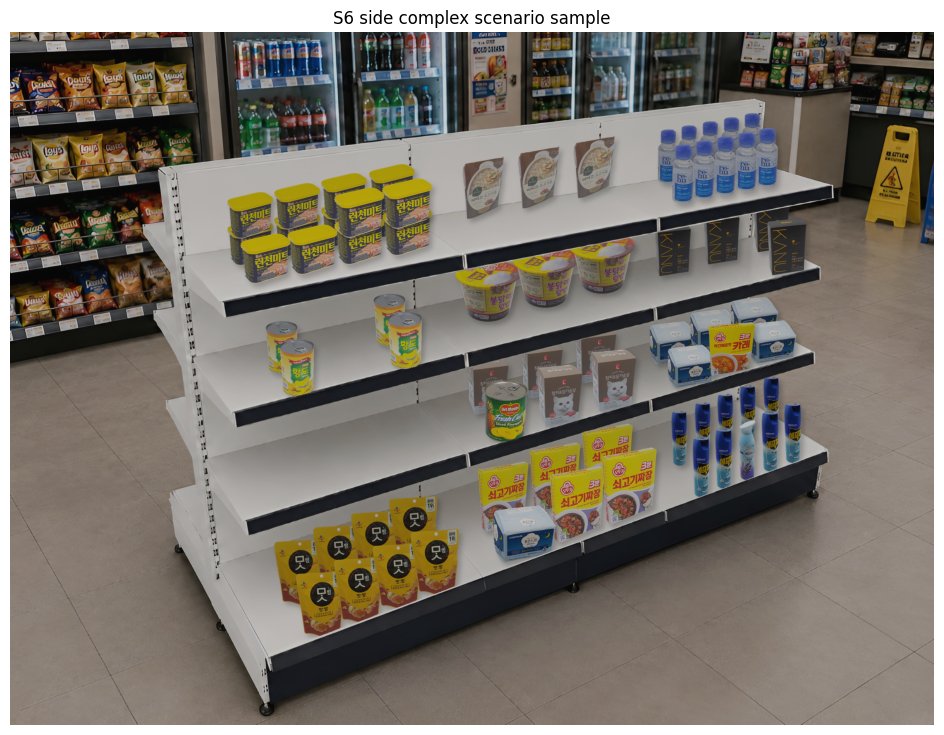

In [ ]:
# ============================================================
# S6 측면 합성 + 이미지/라벨 저장
# 복합 상황: 한 이미지에 여러 문제 공존
# ============================================================

for image_idx in range(NUM_IMAGES):
    seed = BASE_SEED + image_idx

    random.seed(seed)
    synth.reset_random_seed(seed)

    # ------------------------------------------------------------
    # 1. 이미지마다 ctx 새로 생성
    # ------------------------------------------------------------
    ctx = synth.create_synthetic_context(
        base_dir=BASE_DIR,
        background_name='선반이미지_사이드.png',
        seed=seed,
    )

    # ------------------------------------------------------------
    # 2. S6 복합 slot_plan 생성
    # ------------------------------------------------------------
    slot_plan, s6_logs = make_s6_slot_plan(
        ctx=ctx,
        seed=seed
    )

    # ------------------------------------------------------------
    # 3. 렌더링
    # ------------------------------------------------------------
    result, objects, slot_labels = synth.render_from_slot_plan(
        ctx=ctx,
        slot_plan=slot_plan,
        seed=seed
    )

    # ------------------------------------------------------------
    # 4. 조도 변화 적용
    # ------------------------------------------------------------
    result, lighting_info = apply_random_lighting(result)

    # ------------------------------------------------------------
    # 5. 저장 파일명
    # ------------------------------------------------------------
    file_no = start_idx + image_idx

    save_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.png'
    yolo_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.txt'
    json_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.json'

    save_path = IMAGE_DIR / save_name
    product_yolo_path = PRODUCT_YOLO_DIR / yolo_name
    shelf_lip_yolo_path = SHELF_LIP_YOLO_DIR / yolo_name
    json_path = JSON_DIR / json_name

    # ------------------------------------------------------------
    # 6. 이미지 + SAHI 기준 라벨 3종 저장
    # save_sahi_labels()에는 lighting_info 인자가 없으므로 넘기지 않는다.
    # ------------------------------------------------------------
    label_result = labeler.save_sahi_labels(
        result=result,
        objects=objects,
        slot_labels=slot_labels,
        ctx=ctx,
        scenario_code=SCENARIO_CODE,
        scenario_name=SCENARIO_NAME,
        image_path=save_path,
        product_yolo_path=product_yolo_path,
        shelf_lip_yolo_path=shelf_lip_yolo_path,
        slot_json_path=json_path,
        seed=seed,
        view='side',
        settings_extra={
            'excluded_product_ids_for_s5': sorted(list(EXCLUDE_MISPLACED_PRODUCT_IDS)),
            'included_sub_scenarios': [
                'S1_partial_front_missing',
                'S2_empty_front',
                'S3_empty_column',
                'S4_sku_absent',
                'S5_misplaced',
                'S7_lighting_change'
            ],
            'rule': 'Multiple issue types coexist in one side-view image.',
        }
    )

    # ------------------------------------------------------------
    # 7. 저장된 slot_state JSON에 S6 전용 정보 추가
    # ------------------------------------------------------------
    with open(json_path, 'r', encoding='utf-8') as f:
        label_json = json.load(f)

    label_json['lighting_info'] = lighting_info
    label_json['s6_details'] = s6_logs

    # settings 안에도 한 번 더 기록
    if 'settings' not in label_json:
        label_json['settings'] = {}

    label_json['settings']['included_sub_scenarios'] = [
        'S1_partial_front_missing',
        'S2_empty_front',
        'S3_empty_column',
        'S4_sku_absent',
        'S5_misplaced',
        'S7_lighting_change'
    ]
    label_json['settings']['rule'] = 'Multiple issue types coexist in one side-view image.'
    label_json['settings']['excluded_product_ids_for_s5'] = sorted(list(EXCLUDE_MISPLACED_PRODUCT_IDS))

    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(label_json, f, ensure_ascii=False, indent=2)

    saved_paths.append(save_path)
    last_result = result

    generation_logs.append({
        'file_name': save_name,
        'seed': seed,
        'scenario_code': SCENARIO_CODE,
        'scenario_name': SCENARIO_NAME,
        'lighting_info': lighting_info,
        'details': s6_logs,
        'n_objects': len(objects),
        'n_slots': len(slot_labels),
        'image_path': str(save_path),
        'product_yolo_path': str(product_yolo_path),
        'shelf_lip_yolo_path': str(shelf_lip_yolo_path),
        'json_path': str(json_path),
        'label_result': label_result,
    })

    if (image_idx + 1) % 20 == 0:
        print(f'[{image_idx + 1}/{NUM_IMAGES}] 생성 완료:', save_name)

print('S6 생성 완료')
print(f'총 생성 수: {len(saved_paths)}장')
print('이미지 저장 폴더:', IMAGE_DIR)
print('상품 YOLO 저장 폴더:', PRODUCT_YOLO_DIR)
print('선반 앞턱 YOLO-seg 저장 폴더:', SHELF_LIP_YOLO_DIR)
print('slot_state JSON 저장 폴더:', JSON_DIR)

print('처음 5개 파일:')
for p in saved_paths[:5]:
    print('-', p.name)

print('마지막 이미지:', saved_paths[-1])
synth.show_image(last_result, title=f'{SCENARIO_CODE} side complex scenario sample')

In [2]:
# S6 생성 로그 확인
last_log = generation_logs[-1]

print('파일명:', last_log['file_name'])
print('seed:', last_log['seed'])
print('조도:', last_log['lighting_info'])
print('객체 수:', last_log['n_objects'])
print('slot 수:', last_log['n_slots'])

print('\n[S1 앞줄 일부 결손]')
for x in last_log['details']['S1_partial_front_missing']:
    print(x)

print('\n[S2 앞줄 전체 공백]')
for x in last_log['details']['S2_empty_front']:
    print(x)

print('\n[S3 열/라인 단위 공백]')
for x in last_log['details']['S3_empty_column']:
    print(x)

print('\n[S4 SKU 완전 부재]')
for x in last_log['details']['S4_sku_absent']:
    print(x)

print('\n[S5 오진열]')
for x in last_log['details']['S5_misplaced']:
    print(x)